# 🚗 Car Price Prediction

## Oasis Infobyte Data Science Internship — Task 3

### Objective

Build a machine learning model to predict the selling price of
used cars based on different features such as year, present price,
kilometers driven, fuel type, seller type, transmission, and
number of previous owners.

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

# Step 2 — Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Step 3: Load Dataset

In [4]:
df = pd.read_csv("Car details v3.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset Shape: (8128, 13)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


# Step 4: Dataset Inspection

In [5]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape:
(8128, 13)

Column Names:
['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque', 'seats']

Data Types:
name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage           object
engine            object
max_power         object
torque            object
seats            float64
dtype: object

Missing Values:
name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

First 5 Rows:


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


# Step 5: Data Cleaning

In [6]:
# Make a copy of the dataset
df_clean = df.copy()

# Convert columns containing units into numeric values
df_clean["mileage"] = (
    df_clean["mileage"]
    .str.extract(r"([\d.]+)", expand=False)
    .astype(float)
)

df_clean["engine"] = (
    df_clean["engine"]
    .str.extract(r"([\d.]+)", expand=False)
    .astype(float)
)

df_clean["max_power"] = (
    df_clean["max_power"]
    .str.extract(r"([\d.]+)", expand=False)
    .astype(float)
)

# Extract numeric value from torque
df_clean["torque"] = (
    df_clean["torque"]
    .str.extract(r"([\d.]+)", expand=False)
    .astype(float)
)

# Remove rows with missing values
df_clean = df_clean.dropna().reset_index(drop=True)

print("Data cleaning completed!")
print("Original Shape:", df.shape)
print("Cleaned Shape:", df_clean.shape)

print("\nMissing Values After Cleaning:")
print(df_clean.isnull().sum())

Data cleaning completed!
Original Shape: (8128, 13)
Cleaned Shape: (7906, 13)

Missing Values After Cleaning:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
torque           0
seats            0
dtype: int64


# Step 6: Inspect Cleaned Dataset

In [7]:
print("Cleaned Dataset Shape:")
print(df_clean.shape)

print("\nData Types:")
print(df_clean.dtypes)

print("\nMissing Values:")
print(df_clean.isnull().sum())

print("\nFirst 5 Rows:")
display(df_clean.head())

Cleaned Dataset Shape:
(7906, 13)

Data Types:
name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage          float64
engine           float64
max_power        float64
torque           float64
seats            float64
dtype: object

Missing Values:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
torque           0
seats            0
dtype: int64

First 5 Rows:


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,190.0,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,250.0,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,12.7,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,22.4,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,11.5,5.0


# Step 7: Descriptive Statistics

In [8]:
df_clean.describe()

,year,selling_price,km_driven,mileage,engine,max_power,torque,seats
count,7906.000000,7.906000e+03,7.906000e+03,7906.000000,7906.000000,7906.000000,7906.000000,7906.000000
mean,2013.983936,6.498137e+05,6.918866e+04,19.419861,1458.708829,91.587374,168.294141,5.416393
std,3.863695,8.135827e+05,5.679230e+04,4.036263,503.893057,35.747216,97.313384,0.959208
min,1994.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,32.800000,4.800000,2.000000
25%,2012.000000,2.700000e+05,3.500000e+04,16.780000,1197.000000,68.050000,101.000000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.000000,82.000000,154.900000,5.000000
75%,2017.000000,6.900000e+05,9.542500e+04,22.320000,1582.000000,102.000000,202.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,400.000000,789.000000,14.000000


# Step 8: Selling Price Distribution

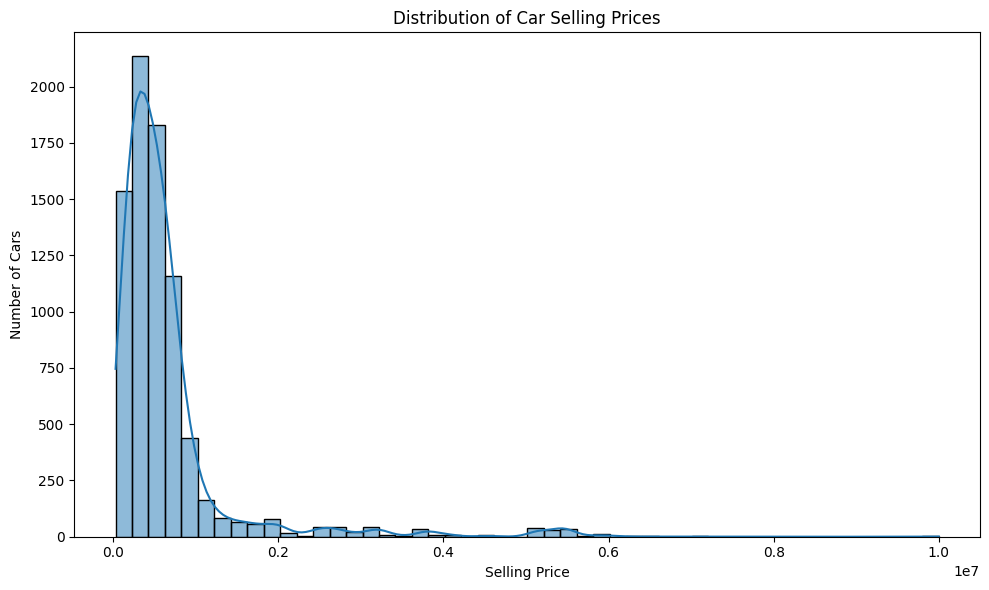

In [9]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df_clean["selling_price"],
    bins=50,
    kde=True
)

plt.title("Distribution of Car Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")

plt.tight_layout()
plt.show()

# Step 9: Selling Price vs Car Year

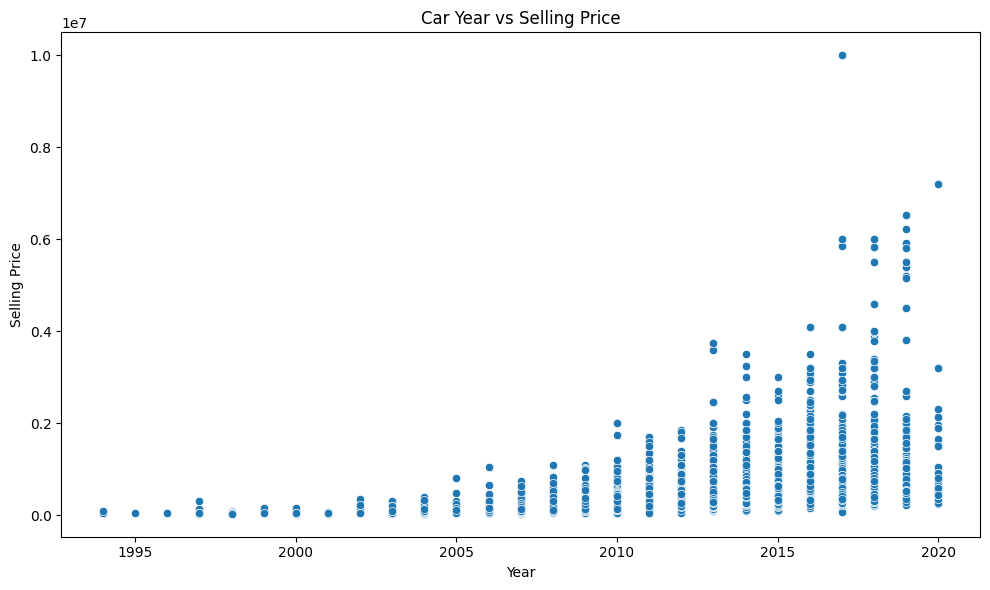

In [10]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="year",
    y="selling_price"
)

plt.title("Car Year vs Selling Price")
plt.xlabel("Year")
plt.ylabel("Selling Price")

plt.tight_layout()
plt.show()

# Step 10: Selling Price vs Kilometers Driven

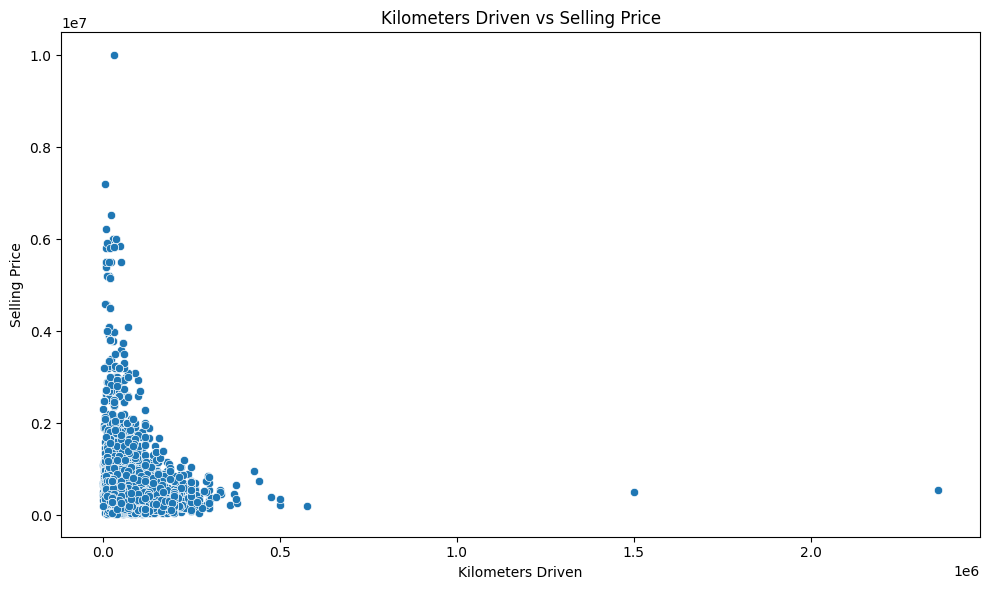

In [11]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="km_driven",
    y="selling_price"
)

plt.title("Kilometers Driven vs Selling Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")

plt.tight_layout()
plt.show()

# Step 11: Fuel Type vs Selling Price

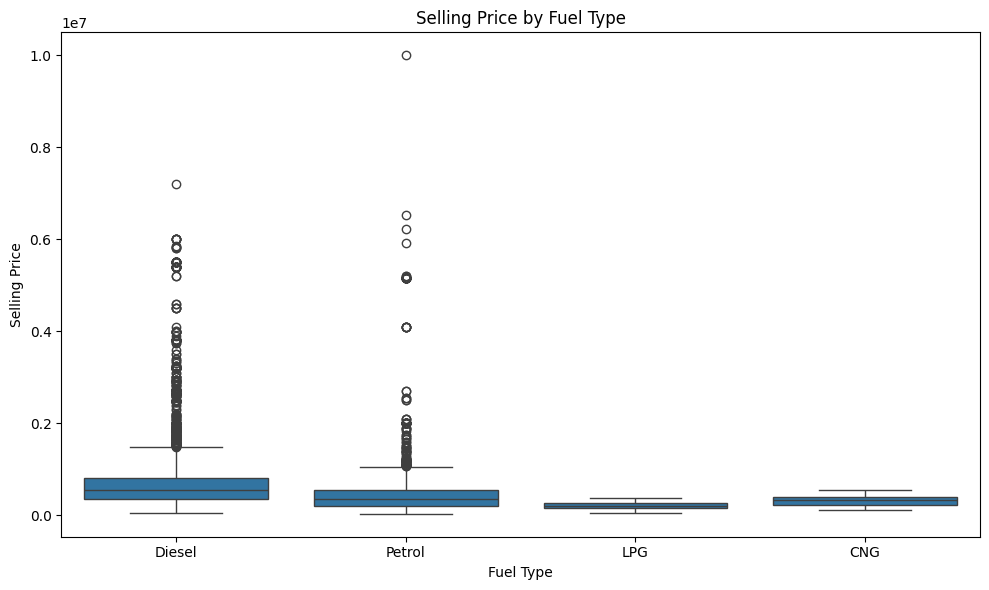

In [12]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="fuel",
    y="selling_price"
)

plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")

plt.tight_layout()
plt.show()

# Step 12: Transmission vs Selling Price

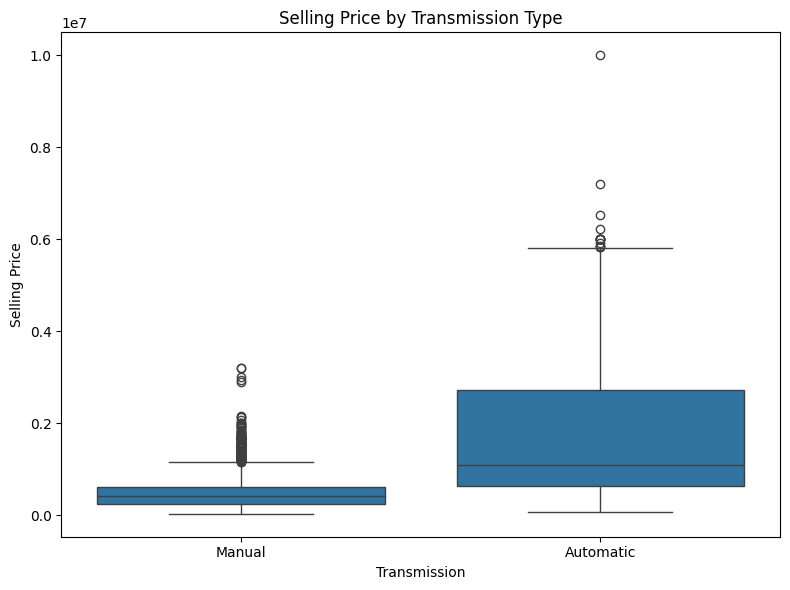

In [13]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df_clean,
    x="transmission",
    y="selling_price"
)

plt.title("Selling Price by Transmission Type")
plt.xlabel("Transmission")
plt.ylabel("Selling Price")

plt.tight_layout()
plt.show()

# Step 13: Correlation Analysis

In [14]:
numeric_columns = [
    "year",
    "km_driven",
    "selling_price",
    "mileage",
    "engine",
    "max_power",
    "torque",
    "seats"
]

correlation_matrix = df_clean[numeric_columns].corr()

print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,year,km_driven,selling_price,mileage,engine,max_power,torque,seats
year,1.000000,-0.428548,0.412302,0.328544,0.018263,0.226598,0.289456,-0.007923
km_driven,-0.428548,1.000000,-0.222158,-0.172980,0.206031,-0.038159,-0.003322,0.227259
selling_price,0.412302,-0.222158,1.000000,-0.126280,0.455682,0.749674,0.619792,0.041617
mileage,0.328544,-0.172980,-0.126280,1.000000,-0.576408,-0.374621,-0.171132,-0.451700
engine,0.018263,0.206031,0.455682,-0.576408,1.000000,0.703975,0.628868,0.611103
max_power,0.226598,-0.038159,0.749674,-0.374621,0.703975,1.000000,0.770206,0.191999
torque,0.289456,-0.003322,0.619792,-0.171132,0.628868,0.770206,1.000000,0.274470
seats,-0.007923,0.227259,0.041617,-0.451700,0.611103,0.191999,0.274470,1.000000


# Step 14: Correlation Heatmap


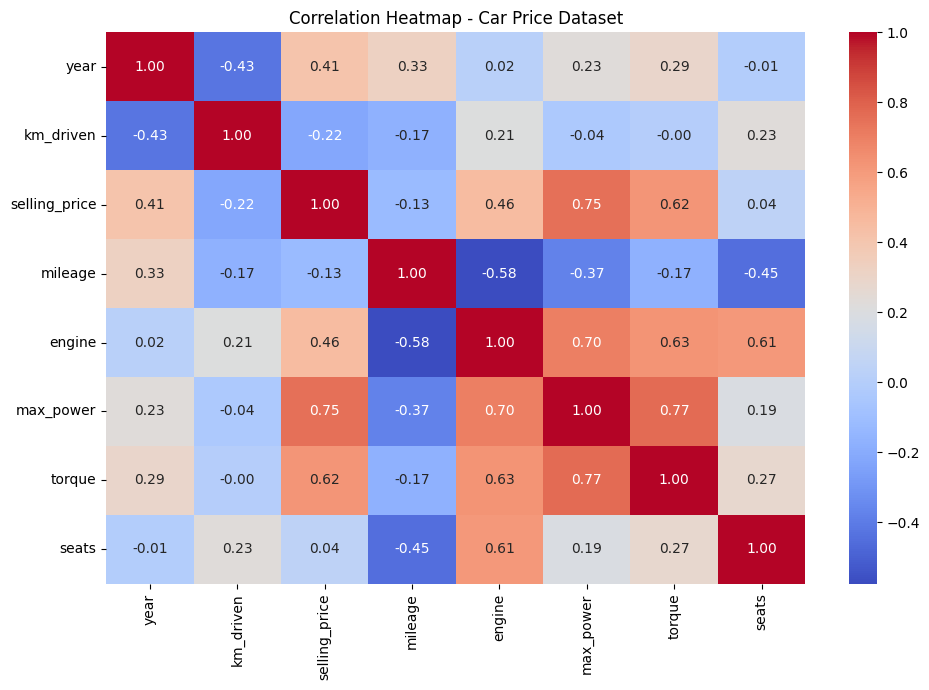

In [15]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap - Car Price Dataset")
plt.tight_layout()
plt.show()

# Step 15: Check Categorical Columns

In [16]:
categorical_columns = [
    "fuel",
    "seller_type",
    "transmission",
    "owner"
]

print("Categorical Columns:")
print(categorical_columns)

for column in categorical_columns:
    print(f"\n{column}:")
    print(df_clean[column].unique())

Categorical Columns:
['fuel', 'seller_type', 'transmission', 'owner']

fuel:
['Diesel' 'Petrol' 'LPG' 'CNG']

seller_type:
['Individual' 'Dealer' 'Trustmark Dealer']

transmission:
['Manual' 'Automatic']

owner:
['First Owner' 'Second Owner' 'Third Owner' 'Fourth & Above Owner'
 'Test Drive Car']


# Step 16: One-Hot Encoding + Feature/Target Separation

In [17]:
# Remove car name because it has many unique values
df_model = df_clean.drop(columns=["name"])

# Separate target variable
X = df_model.drop(columns=["selling_price"])
y = df_model["selling_price"]

# Convert categorical columns into numerical columns
X = pd.get_dummies(
    X,
    columns=["fuel", "seller_type", "transmission", "owner"],
    drop_first=True
)

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFeature Columns:")
print(X.columns.tolist())

Features Shape: (7906, 17)
Target Shape: (7906,)

Feature Columns:
['year', 'km_driven', 'mileage', 'engine', 'max_power', 'torque', 'seats', 'fuel_Diesel', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Manual', 'owner_Fourth & Above Owner', 'owner_Second Owner', 'owner_Test Drive Car', 'owner_Third Owner']


# Step 17: Train-Test Split


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (6324, 17)
Testing Features: (1582, 17)
Training Target: (6324,)
Testing Target: (1582,)


# Step 18: Train Multiple Regression Models

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Create models
linear_model = LinearRegression()

decision_tree_model = DecisionTreeRegressor(
    random_state=42
)

random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train Linear Regression
linear_model.fit(X_train, y_train)

# Train Decision Tree
decision_tree_model.fit(X_train, y_train)

# Train Random Forest
random_forest_model.fit(X_train, y_train)

# Predictions
y_pred_linear = linear_model.predict(X_test)

y_pred_tree = decision_tree_model.predict(X_test)

y_pred_forest = random_forest_model.predict(X_test)

# Step 19: Evaluate All Models

In [20]:
# Calculate metrics for Linear Regression
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

# Calculate metrics for Decision Tree
mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2_tree = r2_score(y_test, y_pred_tree)

# Calculate metrics for Random Forest
mae_forest = mean_absolute_error(y_test, y_pred_forest)
rmse_forest = np.sqrt(mean_squared_error(y_test, y_pred_forest))
r2_forest = r2_score(y_test, y_pred_forest)

# Create comparison table
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae_linear,
        mae_tree,
        mae_forest
    ],
    "RMSE": [
        rmse_linear,
        rmse_tree,
        rmse_forest
    ],
    "R2 Score": [
        r2_linear,
        r2_tree,
        r2_forest
    ]
})

model_comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,270018.740716,465021.132312,0.688983
1,Decision Tree,72939.944164,146734.824376,0.969033
2,Random Forest,61370.201776,109031.093892,0.982902


# Step 20: Actual vs Predicted Prices

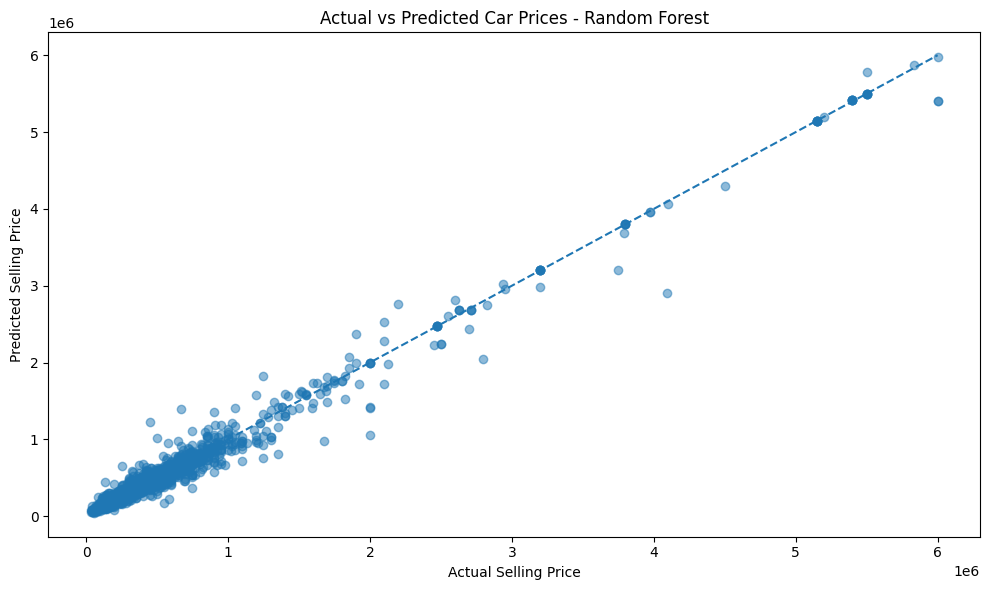

In [21]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred_forest,
    alpha=0.5
)

# Perfect prediction reference line
min_price = min(y_test.min(), y_pred_forest.min())
max_price = max(y_test.max(), y_pred_forest.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.title("Actual vs Predicted Car Prices - Random Forest")
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")

plt.tight_layout()
plt.show()

# Step 21: Feature Importance

In [22]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
)

print("Feature Importance:")
display(feature_importance)

Feature Importance:


,Feature,Importance
4,max_power,0.693815
0,year,0.209859
5,torque,0.037562
1,km_driven,0.018951
2,mileage,0.013932
3,engine,0.010089
10,seller_type_Individual,0.007207
6,seats,0.002729
12,transmission_Manual,0.002264
14,owner_Second Owner,0.001299


# Step 21.1: Feature Importance Visualization

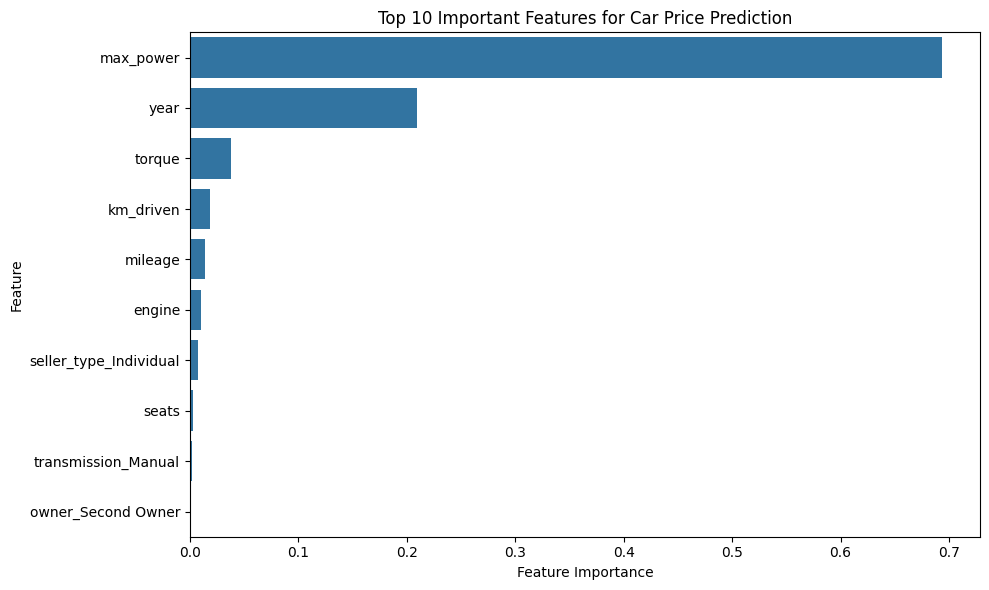

In [23]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features for Car Price Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# Step 22: Actual vs Predicted Price for Sample Cars

In [24]:
comparison_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred_forest
})

comparison_df["Difference"] = (
    comparison_df["Actual Price"]
    - comparison_df["Predicted Price"]
)

comparison_df.head(10)

,Actual Price,Predicted Price,Difference
0,501000,563256.636667,-62256.636667
1,440000,519853.333333,-79853.333333
2,140000,160989.980000,-20989.980000
3,476999,398159.970000,78839.030000
4,620000,594299.980000,25700.020000
5,380000,322980.000000,57020.000000
6,360000,522239.820000,-162239.820000
7,185000,148210.000000,36790.000000
8,157000,125817.500000,31182.500000
9,600000,407429.940000,192570.060000
